In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns

%matplotlib inline


In [44]:
df = pd.read_csv('Final Data integraated.csv')
df =df[
    (df['category'] != 'Unknown')
]


In [45]:
df['duration_seconds'].max()

57468

In [23]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 url                 0
title               0
category            0
duration_seconds    0
view_count          0
like_count          0
comment_count       0
dtype: int64


In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1794
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   url               1500 non-null   object
 1   title             1500 non-null   object
 2   category          1500 non-null   object
 3   duration_seconds  1500 non-null   int64 
 4   view_count        1500 non-null   int64 
 5   like_count        1500 non-null   int64 
 6   comment_count     1500 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 93.8+ KB
None


In [25]:
print(df.describe())

       duration_seconds    view_count    like_count  comment_count
count       1500.000000  1.500000e+03  1.500000e+03     1500.00000
mean         981.242000  1.406007e+07  2.763090e+05     2569.28600
std         4138.492144  5.006171e+07  9.919043e+05     9764.47742
min            4.000000  1.000000e+00  0.000000e+00        0.00000
25%           20.000000  2.237402e+05  5.379500e+03       87.00000
50%           50.000000  1.513714e+06  3.127350e+04      404.00000
75%          445.750000  8.859606e+06  1.863720e+05     1632.75000
max        57468.000000  1.225592e+09  1.979052e+07   260423.00000


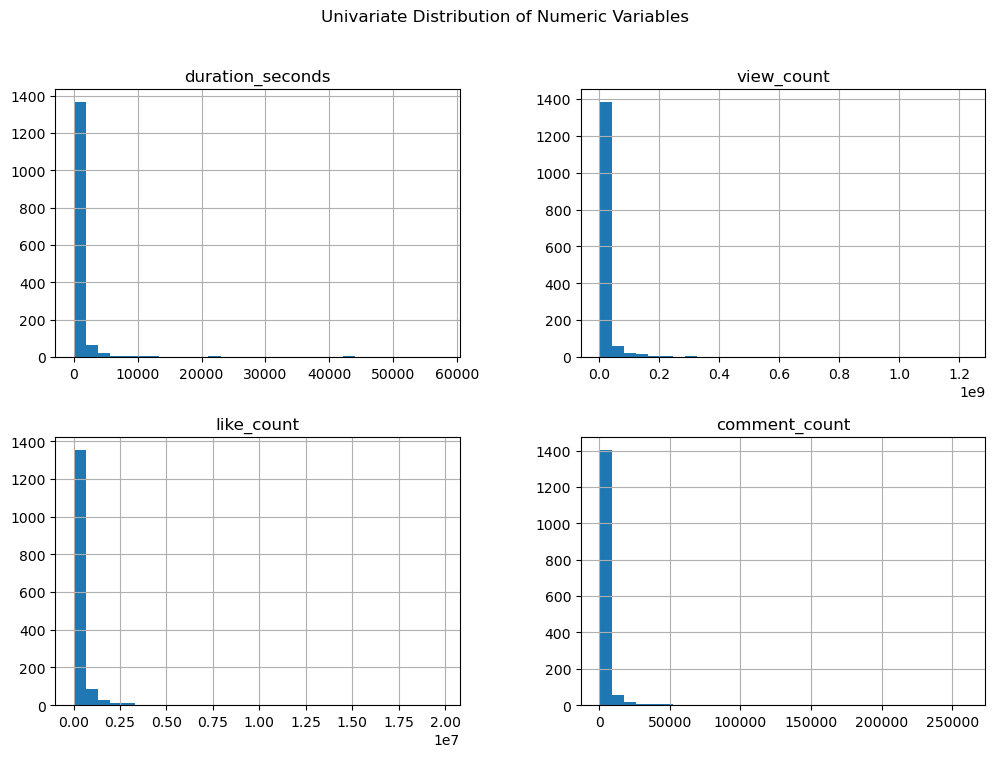

In [26]:
numeric_cols = [
    'duration_seconds',
    'view_count',
    'like_count',
    'comment_count'
]

df[numeric_cols].hist(bins=30, figsize=(12,8))
plt.suptitle('Univariate Distribution of Numeric Variables')
plt.show()


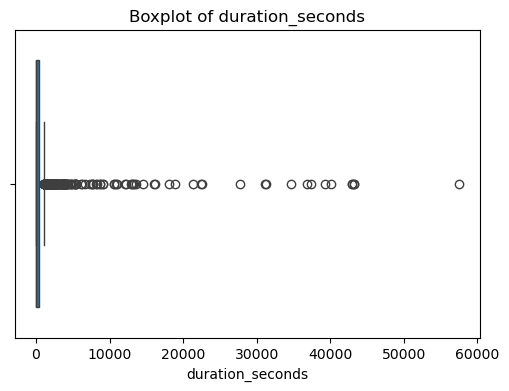

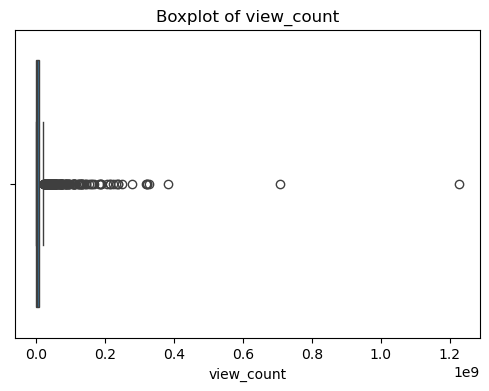

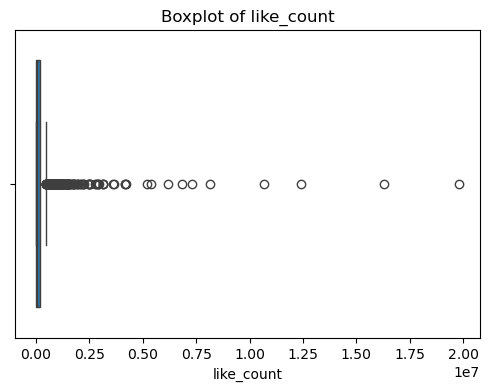

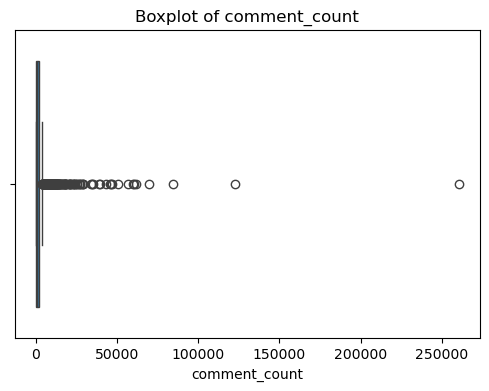

In [27]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [28]:
category_counts = df['category'].value_counts()
print(category_counts)

category
photography tutorials    172
gaming                   171
travelling               165
vlogs                    163
funny content            155
python tutorial          155
religious content        140
cinema content           139
music                    133
food recipes             107
Name: count, dtype: int64


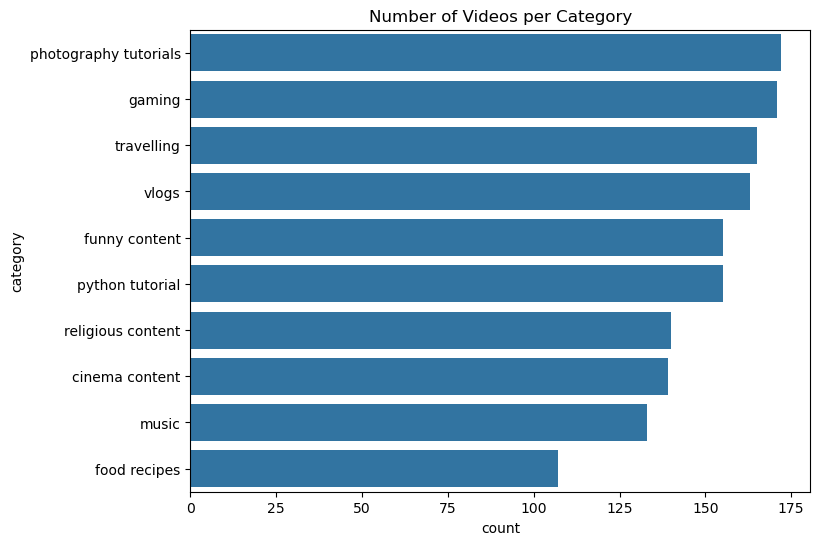

In [29]:
plt.figure(figsize=(8,6))
sns.countplot(y='category', data=df, order=category_counts.index)
plt.title('Number of Videos per Category')
plt.show()


In [30]:
print("Correlation Matrix:\n", df[numeric_cols].corr())
print("\nCovariance Matrix:\n", df[numeric_cols].cov())

Correlation Matrix:
                   duration_seconds  view_count  like_count  comment_count
duration_seconds          1.000000   -0.045387   -0.042242       0.064343
view_count               -0.045387    1.000000    0.876856       0.195249
like_count               -0.042242    0.876856    1.000000       0.250490
comment_count             0.064343    0.195249    0.250490       1.000000

Covariance Matrix:
                   duration_seconds    view_count    like_count  comment_count
duration_seconds      1.712712e+07 -9.403329e+09 -1.734023e+08   2.600116e+06
view_count           -9.403329e+09  2.506175e+15  4.354155e+13   9.544295e+10
like_count           -1.734023e+08  4.354155e+13  9.838741e+11   2.426106e+09
comment_count         2.600116e+06  9.544295e+10  2.426106e+09   9.534502e+07


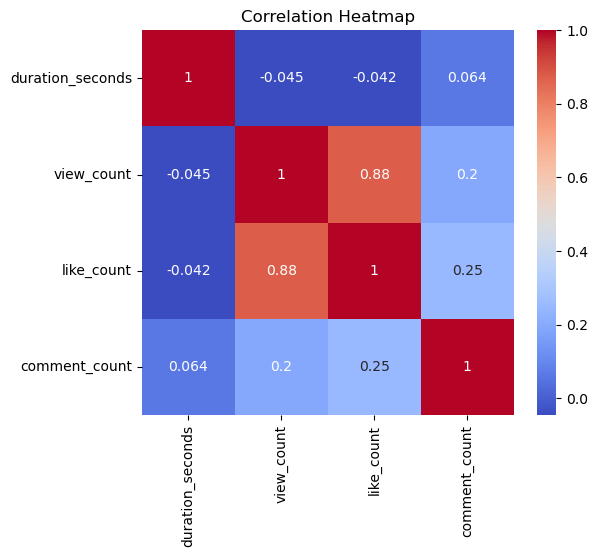

In [31]:
plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

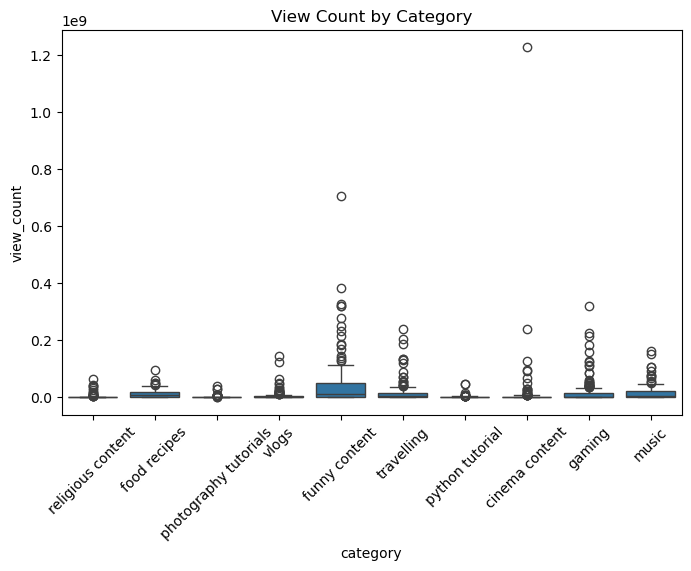

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x='category', y='view_count', data=df)
plt.xticks(rotation=45)
plt.title('View Count by Category')
plt.show()


In [14]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

In [15]:
for col in numeric_cols:
    print(f"{col} outliers:", len(detect_outliers_iqr(df, col)))

duration_seconds outliers: 222
view_count outliers: 205
like_count outliers: 199
comment_count outliers: 206


In [16]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

In [17]:
for col in numeric_cols:
    print(f"{col} outliers:", len(detect_outliers_iqr(df, col)))

duration_seconds outliers: 0
view_count outliers: 0
like_count outliers: 0
comment_count outliers: 0


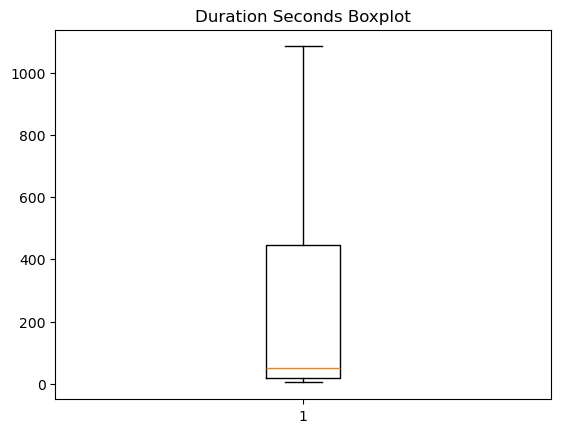

In [18]:
plt.boxplot(df['duration_seconds'])
plt.title('Duration Seconds Boxplot')
plt.show()


In [34]:
df['engagement'] = (
    df['like_count'] + df['comment_count']
) / df['view_count']


In [37]:
df = df.dropna(subset=['duration_seconds'])

In [39]:
max_duration = max(df['duration_seconds'].max(), 3600)

# Create fixed-duration buckets
df['duration_bucket'] = pd.cut(
    df['duration_seconds'],
    bins=[0, 300, 900, 3600, max_duration],
    labels=['Short', 'Medium', 'Long', 'Very Long'],
    include_lowest=True
)



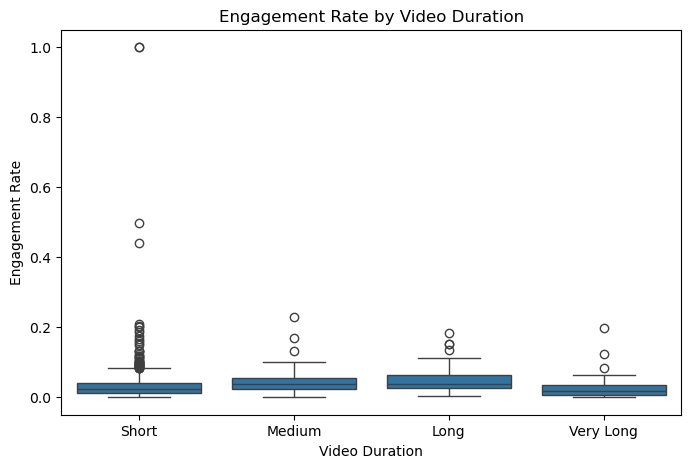

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x='duration_bucket', y='engagement', data=df)
plt.title('Engagement Rate by Video Duration')
plt.xlabel('Video Duration')
plt.ylabel('Engagement Rate')
plt.show()

In [41]:
df

,url,title,category,duration_seconds,view_count,like_count,comment_count,duration_bucket,engagement
0,https://www.youtube.com/watch?v=zuiU_mD-p0c,This ONE Bible Verse Boosted My Faith #Shorts,religious content,55,1097261,165069,45568,Short,0.191966
1,https://www.youtube.com/watch?v=ztFAl1To3Wo,Ever tried Crispy Banana Bonda 🤤#shorts,food recipes,52,95273478,1468403,6862,Short,0.015485
2,https://www.youtube.com/watch?v=zpQ_jC57W4E,Camera Flash tip for beginners - Godox v1 lamp...,photography tutorials,23,479077,9712,92,Short,0.020464
3,https://www.youtube.com/watch?v=zlomFl0KSVQ,Extend Background Photo - Short Photoshop Tuto...,photography tutorials,31,198509,7118,24,Short,0.035978
4,https://www.youtube.com/watch?v=zcTCJCLCKEA,Grand Celebration of the Twins with Special Pe...,vlogs,838,4989,238,17,Medium,0.051112
...,...,...,...,...,...,...,...,...,...
1790,https://www.youtube.com/watch?v=-3bG5bzUKmI,Instant Crispy Potato Triangles Recipe | Party...,food recipes,21,13172670,195142,485,Short,0.014851
1791,https://www.youtube.com/watch?v=-3Tc6b74TXE,Singapore ki jeans😂 #shorts #funny #comedy,funny content,60,6596645,192107,152,Short,0.029145
1792,https://www.youtube.com/watch?v=-30pyWb7mxs,The male need and urge for FREE #warframe #gam...,gaming,60,150360,9998,192,Short,0.067771
1793,https://www.youtube.com/watch?v=-2KIoyDX8Dc,Steal our UDAIPUR Travel Guide ✨💕 #udaipur #tr...,travelling,59,1538968,52389,174,Short,0.034155


In [42]:
df.tail()

,url,title,category,duration_seconds,view_count,like_count,comment_count,duration_bucket,engagement
1790,https://www.youtube.com/watch?v=-3bG5bzUKmI,Instant Crispy Potato Triangles Recipe | Party...,food recipes,21,13172670,195142,485,Short,0.014851
1791,https://www.youtube.com/watch?v=-3Tc6b74TXE,Singapore ki jeans😂 #shorts #funny #comedy,funny content,60,6596645,192107,152,Short,0.029145
1792,https://www.youtube.com/watch?v=-30pyWb7mxs,The male need and urge for FREE #warframe #gam...,gaming,60,150360,9998,192,Short,0.067771
1793,https://www.youtube.com/watch?v=-2KIoyDX8Dc,Steal our UDAIPUR Travel Guide ✨💕 #udaipur #tr...,travelling,59,1538968,52389,174,Short,0.034155
1794,https://www.youtube.com/watch?v=-0-U20gTt38,How to do Light Painting Photography using the...,photography tutorials,18,536591,18975,83,Short,0.035517


In [43]:
df.head(40)

,url,title,category,duration_seconds,view_count,like_count,comment_count,duration_bucket,engagement
0,https://www.youtube.com/watch?v=zuiU_mD-p0c,This ONE Bible Verse Boosted My Faith #Shorts,religious content,55,1097261,165069,45568,Short,0.191966
1,https://www.youtube.com/watch?v=ztFAl1To3Wo,Ever tried Crispy Banana Bonda 🤤#shorts,food recipes,52,95273478,1468403,6862,Short,0.015485
2,https://www.youtube.com/watch?v=zpQ_jC57W4E,Camera Flash tip for beginners - Godox v1 lamp...,photography tutorials,23,479077,9712,92,Short,0.020464
3,https://www.youtube.com/watch?v=zlomFl0KSVQ,Extend Background Photo - Short Photoshop Tuto...,photography tutorials,31,198509,7118,24,Short,0.035978
4,https://www.youtube.com/watch?v=zcTCJCLCKEA,Grand Celebration of the Twins with Special Pe...,vlogs,838,4989,238,17,Medium,0.051112
5,https://www.youtube.com/watch?v=z_DgvMHnfjc,My go to settings for sports photography in ma...,photography tutorials,14,2327745,95924,583,Short,0.041459
6,https://www.youtube.com/watch?v=zY6MHzF8ZN0,Just winter things 🥹 #relatable #funny #indian...,funny content,10,15208708,373311,495,Short,0.024578
7,https://www.youtube.com/watch?v=zR_IarVr2AI,Places In Real Life #travel #explore #adventur...,travelling,16,206057629,6853449,8625,Short,0.033302
8,https://www.youtube.com/watch?v=zKCCTN736Bs,#vlog | Saturday Vachindante Apudapudu Inthe 😡...,vlogs,1753,37413,808,146,Long,0.025499
9,https://www.youtube.com/watch?v=zIbCVHDBqOI,Episode -1 About lens focusing AF & MF | Telug...,photography tutorials,60,176802,14646,62,Short,0.083189


In [46]:
df.to_csv('Final Integrated part 2.csv', index=False)


print("Integrated dataset saved to 'Final Integrated part 2.csv'")

Integrated dataset saved to 'Final Integrated part 2.csv'
